<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/10_Deep_Learning_Multilayer_Perceptrons_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1 Multilayer Perceptrons

In the previous chapter, we used **softmax regression**, which learns a linear relationship between the input features and the output classes. While effective for simple problems, many real-world datasets contain complex patterns that cannot be represented by a single linear transformation.

A **multilayer perceptron (MLP)** addresses this limitation by introducing one or more **hidden layers** and **nonlinear activation functions**, allowing the model to learn much richer representations of the input data.

### Hidden Layers

A linear model assumes that the relationship between the input features and the output can be represented by a single linear transformation. This assumption is often too restrictive for real-world problems.

For example, recognizing whether an image contains a cat or a dog depends on combinations of many pixels rather than the brightness of individual pixels. Similarly, language, speech, and financial data often contain complex nonlinear relationships.

A **hidden layer** transforms the input into a new representation before making the final prediction. By stacking multiple hidden layers, neural networks can gradually learn increasingly abstract features from the data.

### Incorporating Hidden Layers

To overcome the limitations of linear models, we introduce one or more **hidden layers** between the input and output layers. Each hidden layer learns a new representation of the input, allowing the network to capture increasingly complex patterns.

A **multilayer perceptron (MLP)** is formed by stacking fully connected layers. Information flows from the **input layer**, through one or more **hidden layers**, and finally to the **output layer**, where the prediction is produced.

> **Figure below is an example of a multilayer perceptron with four input features, one hidden layer containing five neurons, and three output neurons.

In this example:

- The **input layer** receives the original features.
- The **hidden layer** learns intermediate feature representations.
- The **output layer** produces the final prediction.
- Each neuron in one layer is connected to **every neuron** in the next layer, making the network **fully connected**.

Notice that the input layer simply passes data into the network and does not perform any computations. The model's learnable computations occur in the hidden and output layers.
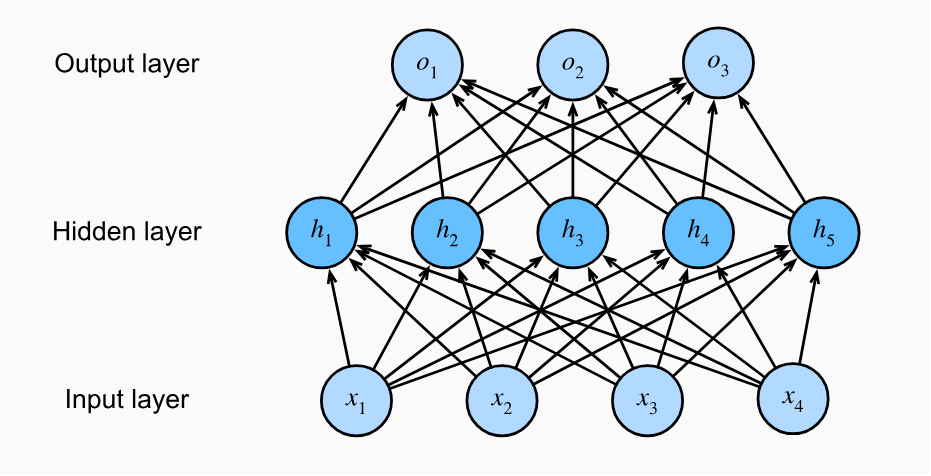

> **Note:** The number of hidden layers and the number of neurons within each layer are design choices called **hyperparameters**. These values influence the model's ability to learn complex patterns.

### From Linear to Nonlinear

Adding hidden layers alone does **not** make a neural network more powerful if every layer performs only a linear transformation.

For a network with one hidden layer, the computations are

$$
\mathbf{H} = \mathbf{X}\mathbf{W}^{(1)} + \mathbf{b}^{(1)}
$$

$$
\mathbf{O} = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}
$$

where:

- **X** is the input data,
- **H** is the hidden layer output,
- **O** is the final output,
- **W** represents the weights, and
- **b** represents the bias terms.

Since both layers perform only linear transformations, they can be combined into a single linear transformation. As a result, the network is still equivalent to a linear model and cannot learn complex nonlinear relationships.

To overcome this limitation, we introduce a **nonlinear activation function** after each hidden layer. The hidden layer is now computed as

$$
\mathbf{H} = \sigma\left(\mathbf{X}\mathbf{W}^{(1)} + \mathbf{b}^{(1)}\right)
$$

where $\sigma(\cdot)$ is an activation function such as the **Rectified Linear Unit (ReLU)**.

Because the activation function is nonlinear, the network can no longer be reduced to a single linear transformation. This enables multilayer perceptrons to learn complex patterns that linear models cannot represent.

As additional hidden layers are stacked, the network learns increasingly abstract feature representations, allowing it to solve more challenging prediction tasks.

### Universal Approximation Theorem

The **Universal Approximation Theorem** is a mathematical result showing that a neural network with at least one hidden layer and enough neurons can approximate almost any continuous function.

In other words, given enough neurons and appropriate weights, a neural network can learn very complex relationships between inputs and outputs.

However, this does **not** mean that training such a network is easy. Choosing the right architecture, finding the optimal weights, and providing enough training data remain challenging tasks.

In practice, deep networks with multiple hidden layers are often more efficient than a single hidden layer with a very large number of neurons because they learn hierarchical feature representations.

## 5.1.2 Activation Functions

An **activation function** introduces **nonlinearity** into a neural network. Without an activation function, every layer would perform only a linear transformation, and the entire network would behave like a simple linear model.

By applying an activation function after each hidden layer, neural networks can learn complex patterns and relationships that linear models cannot represent.

Several activation functions have been proposed, but the **Rectified Linear Unit (ReLU)** is the most widely used in modern deep learning because it is simple, computationally efficient, and performs well across many applications.

### ReLU Function

The **Rectified Linear Unit (ReLU)** is the most commonly used activation function in deep learning. It is defined as

$$
\mathrm{ReLU}(x)=\max(0,x).
$$

This means:

- If the input is **positive**, the output equals the input.
- If the input is **negative**, the output is **0**.

The ReLU function is simple to compute and helps neural networks learn complex nonlinear relationships while making training more efficient.

The figure below illustrates the ReLU function.

In [ ]:
!pip install --q D2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 2.8 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from d2l import tensorflow as d2l

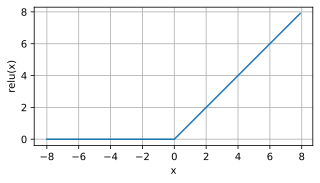

In [ ]:
x = tf.Variable(tf.range(-8.0, 8.0, 0.1), dtype=tf.float32)
y = tf.nn.relu(x)
d2l.plot(x.numpy(), y.numpy(), 'x', 'relu(x)', figsize=(5, 2.5))

During training, neural networks compute the derivative of the activation function to update the model's weights. For the ReLU function, the derivative is

- **0** when the input is negative.
- **1** when the input is positive.

This simple derivative makes optimization efficient and helps reduce the vanishing gradient problem commonly encountered in deep neural networks.

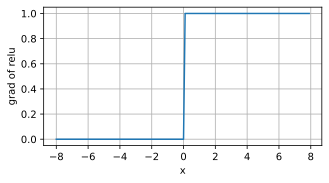

In [ ]:
with tf.GradientTape() as t:
    y = tf.nn.relu(x)
d2l.plot(x.numpy(), t.gradient(y, x).numpy(), 'x', 'grad of relu',
         figsize=(5, 2.5))


## Sigmoid Function

The **sigmoid** activation function maps any input value to a number between **0 and 1**, making it useful when a model needs to produce probabilities.

It is defined as

$$
\sigma(x)=\frac{1}{1+e^{-x}}.
$$

Key characteristics:

- Large negative inputs produce values close to **0**.
- An input of **0** produces an output of **0.5**.
- Large positive inputs produce values close to **1**.

The figure below illustrates the sigmoid function.

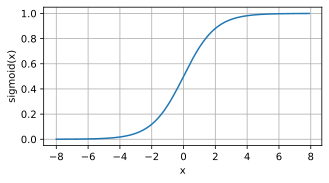

In [ ]:
y = tf.nn.sigmoid(x)
d2l.plot(x.numpy(), y.numpy(), 'x', 'sigmoid(x)', figsize=(5, 2.5))


Although sigmoid was widely used in early neural networks, it is no longer the preferred activation function for hidden layers.

The reason is that for very large positive or negative inputs, the sigmoid function becomes nearly flat. In these regions, its derivative is close to **0**, causing gradients to become very small during backpropagation. As a result, learning slows down, a problem known as the **vanishing gradient problem**.

Today, sigmoid is primarily used in the **output layer of binary classification models**, while **ReLU** is typically used in hidden layers.

Unlike softmax, which produces probabilities across multiple classes, the sigmoid function produces a single probability between 0 and 1 and is therefore commonly used for binary classification problems.

## Tanh Function

The **hyperbolic tangent (tanh)** activation function maps any input value to a number between **-1 and 1**.

It is defined as

$$
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}.
$$

Key characteristics:

- Large negative inputs produce values close to **-1**.
- An input of **0** produces an output of **0**.
- Large positive inputs produce values close to **1**.

The figure below illustrates the tanh function.

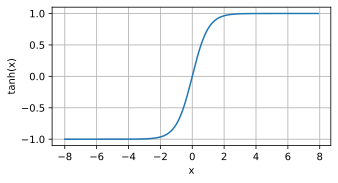

In [ ]:
y = tf.nn.tanh(x)
d2l.plot(x.numpy(), y.numpy(), 'x', 'tanh(x)', figsize=(5, 2.5))

Like the sigmoid function, tanh is nonlinear and was widely used in early neural networks. Unlike sigmoid, however, its outputs are centered around **0**, which often makes optimization easier.

Although tanh performs better than sigmoid in many cases, it still suffers from the **vanishing gradient problem** for very large positive or negative inputs. For this reason, **ReLU** has become the preferred activation function for most hidden layers in modern deep neural networks.

Today, tanh is primarily used in some **recurrent neural networks (RNNs)** and **Long Short-Term Memory (LSTM)** networks, where outputs between **-1 and 1** are useful for representing the internal state of the network.

## Summary

In this section, we introduced the **multilayer perceptron (MLP)**, the simplest type of deep neural network. By adding one or more **hidden layers** and applying **nonlinear activation functions**, MLPs can learn complex patterns that cannot be captured by linear models alone.

We also examined three common activation functions:

- **ReLU:** The most widely used activation function for hidden layers because it is simple, computationally efficient, and helps reduce the vanishing gradient problem.
- **Sigmoid:** Produces outputs between **0 and 1** and is commonly used in the output layer of binary classification models.
- **Tanh:** Produces outputs between **−1 and 1** and is often used in recurrent neural networks (RNNs) and Long Short-Term Memory (LSTM) networks.

These concepts form the foundation for training deeper neural networks and will be used throughout the remainder of the course.